# Análise de Séries Temporais por Estado
Este notebook consolida as análises de RJ, SP e RS.

## Estado: RJ

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
df = pd.read_csv('datasets/products_4.csv')

In [2]:
df_rj = df[df['Proj_State'] == 'RJ']
df_rj.drop(columns=['Prod_Desc', 'Sub_Name', 'ID_Proj', 'Proj_Name', 'Proj_City'], inplace=True)
df_rj.head()

C:\Users\celso\AppData\Local\Temp\ipykernel_16296\3942908168.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_rj.drop(columns=['Prod_Desc', 'Sub_Name', 'ID_Proj', 'Proj_Name', 'Proj_City'], inplace=True)


,Cat_Name,BOM_Quant,Proj_State,Proj_Date
20,Madeiras,500.0,RJ,2023-09-06
22,Madeiras,500.0,RJ,2023-09-06
52,Infraestrutura,16.0,RJ,2023-09-20
53,Infraestrutura,16.0,RJ,2023-09-20
68,Infraestrutura,15.0,RJ,2023-09-22


In [3]:
df_rj.isnull().sum()

Cat_Name      0
BOM_Quant     0
Proj_State    0
Proj_Date     0
dtype: int64

### Criando um dataset para cada categoria que sera modelada

In [4]:
df_rj_ferragens = df_rj[df_rj['Cat_Name'] == 'Ferragens']
df_rj_construcao_civil = df_rj[df_rj['Cat_Name'] == 'Construção Civil']
df_rj_materiais_eletricos = df_rj[df_rj['Cat_Name'] == 'Materiais Elétricos']

### Agrupamento e Soma de BOM_Quant por Data

In [5]:
df_rj_ferragens_grouped = df_rj_ferragens.groupby('Proj_Date').agg({'BOM_Quant': 'sum'}).reset_index()
df_rj_construcao_civil_grouped = df_rj_construcao_civil.groupby('Proj_Date').agg({'BOM_Quant': 'sum'}).reset_index()
df_rj_materiais_eletricos_grouped = df_rj_materiais_eletricos.groupby('Proj_Date').agg({'BOM_Quant': 'sum'}).reset_index()

In [6]:
n_duplicates = df_rj_ferragens_grouped.duplicated().sum()
print(f'Número de duplicados: {n_duplicates}')

n_duplicates = df_rj_construcao_civil_grouped.duplicated().sum()
print(f'Número de duplicados: {n_duplicates}')

n_duplicates = df_rj_materiais_eletricos_grouped.duplicated().sum()
print(f'Número de duplicados: {n_duplicates}')


Número de duplicados: 0
Número de duplicados: 0
Número de duplicados: 0


In [7]:
# Verificando se há valores zero ou negativos
print(df_rj_ferragens_grouped[df_rj_ferragens_grouped['BOM_Quant'] <= 0].shape[0])
print(df_rj_construcao_civil_grouped[df_rj_construcao_civil_grouped['BOM_Quant'] <= 0].shape[0])
print(df_rj_materiais_eletricos_grouped[df_rj_materiais_eletricos_grouped['BOM_Quant'] <= 0].shape[0])


0
0
0


In [8]:
#df_rj_ferragens_grouped.to_csv('../Data/PreparedData/RJ/RJ_FERRAGENS.csv', index=False)
#df_rj_construcao_civil_grouped.to_csv('../Data/PreparedData/RJ/RJ_CONSTRUCAO_CIVIL.csv', index=False)
#df_rj_materiais_eletricos_grouped.to_csv('../Data/PreparedData/RJ/RJ_MATERIAIS_ELETRICOS.csv', index=False)

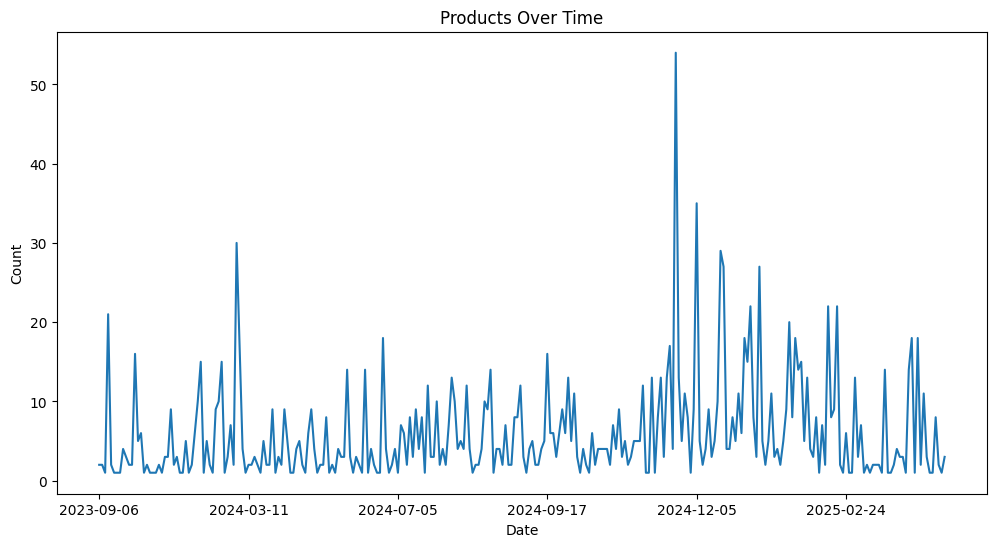

In [9]:
plt.figure(figsize=(12, 6))
df_rj.groupby('Proj_Date').size().plot()
plt.title('Products Over Time')
plt.xlabel('Date')
plt.ylabel('Count')
plt.show()

### Criando datasets semanais

In [10]:
df_rj_ferragens_grouped['Proj_Date'] = pd.to_datetime(df_rj_ferragens_grouped['Proj_Date'])  
df_rj_construcao_civil_grouped['Proj_Date'] = pd.to_datetime(df_rj_construcao_civil_grouped['Proj_Date'])  
df_rj_materiais_eletricos_grouped['Proj_Date'] = pd.to_datetime(df_rj_materiais_eletricos_grouped['Proj_Date'])  
  
df_rj_ferragens_grouped.set_index('Proj_Date', inplace=True)  
df_rj_construcao_civil_grouped.set_index('Proj_Date', inplace=True)  
df_rj_materiais_eletricos_grouped.set_index('Proj_Date', inplace=True) 

In [11]:
df_rj_ferragens_semanal = df_rj_ferragens_grouped.resample('W').sum().reset_index()  
df_rj_construcao_civil_semanal = df_rj_construcao_civil_grouped.resample('W').sum().reset_index()  
df_rj_materiais_eletricos_semanal = df_rj_materiais_eletricos_grouped.resample('W').sum().reset_index() 


#df_rj_ferragens_semanal.to_csv('../Data/PreparedData/RJ/Semanal/RJ_FERRAGENS.csv', index=False)
#df_rj_construcao_civil_semanal.to_csv('../Data/PreparedData/RJ/Semanal/RJ_CONSTRUCAO_CIVIL.csv', index=False)
#df_rj_materiais_eletricos_semanal.to_csv('../Data/PreparedData/RJ/Semanal/RJ_MATERIAIS_ELETRICOS.csv', index=False)

### Criando datasets quinzenais

In [12]:
df_rj_ferragens_quinzenal = df_rj_ferragens_grouped.resample('15D').sum().reset_index()  
df_rj_construcao_civil_quinzenal = df_rj_construcao_civil_grouped.resample('15D').sum().reset_index()  
df_rj_materiais_eletricos_quinzenal = df_rj_materiais_eletricos_grouped.resample('15D').sum().reset_index()  

#df_rj_ferragens_quinzenal.to_csv('../Data/PreparedData/RJ/Quinzenal/RJ_FERRAGENS.csv', index=False)
#df_rj_construcao_civil_quinzenal.to_csv('../Data/PreparedData/RJ/Quinzenal/RJ_CONSTRUCAO_CIVIL.csv', index=False)
#df_rj_materiais_eletricos_quinzenal.to_csv('../Data/PreparedData/RJ/Quinzenal/RJ_MATERIAIS_ELETRICOS.csv', index=False)

## Estado: SP

In [13]:
df_sp = df[df['Proj_State'] == 'SP']
df_sp.drop(columns=['Prod_Desc', 'Sub_Name', 'ID_Proj', 'Proj_Name', 'Proj_City'], inplace=True)
df_sp.head()

C:\Users\celso\AppData\Local\Temp\ipykernel_16296\3807528862.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_sp.drop(columns=['Prod_Desc', 'Sub_Name', 'ID_Proj', 'Proj_Name', 'Proj_City'], inplace=True)


,Cat_Name,BOM_Quant,Proj_State,Proj_Date
2,Construção Civil,136.0,SP,2023-09-05
3,Infraestrutura,104.0,SP,2023-09-05
8,Infraestrutura,2.0,SP,2023-09-06
9,Infraestrutura,2.0,SP,2023-09-06
10,Infraestrutura,2.0,SP,2023-09-06


In [14]:
df_sp.isnull().sum()

Cat_Name      0
BOM_Quant     0
Proj_State    0
Proj_Date     0
dtype: int64

### Criando um dataset para cada categoria que sera modelada

In [15]:
df_sp_ferragens = df_sp[df_sp['Cat_Name'] == 'Ferragens']
df_sp_construcao_civil = df_sp[df_sp['Cat_Name'] == 'Construção Civil']
df_sp_materiais_eletricos = df_sp[df_sp['Cat_Name'] == 'Materiais Elétricos']

### Agrupamento e Soma de BOM_Quant por Data

In [16]:
df_sp_ferragens_grouped = df_sp_ferragens.groupby('Proj_Date').agg({'BOM_Quant': 'sum'}).reset_index()
df_sp_construcao_civil_grouped = df_sp_construcao_civil.groupby('Proj_Date').agg({'BOM_Quant': 'sum'}).reset_index()
df_sp_materiais_eletricos_grouped = df_sp_materiais_eletricos.groupby('Proj_Date').agg({'BOM_Quant': 'sum'}).reset_index()

In [17]:
n_duplicates = df_sp_ferragens_grouped.duplicated().sum()
print(f'Número de duplicados: {n_duplicates}')

n_duplicates = df_sp_construcao_civil_grouped.duplicated().sum()
print(f'Número de duplicados: {n_duplicates}')

n_duplicates = df_sp_materiais_eletricos_grouped.duplicated().sum()
print(f'Número de duplicados: {n_duplicates}')


Número de duplicados: 0
Número de duplicados: 0
Número de duplicados: 0


In [18]:
# Verificando se há valores zero ou negativos
print(df_sp_ferragens_grouped[df_sp_ferragens_grouped['BOM_Quant'] <= 0].shape[0])
print(df_sp_construcao_civil_grouped[df_sp_construcao_civil_grouped['BOM_Quant'] <= 0].shape[0])
print(df_sp_materiais_eletricos_grouped[df_sp_materiais_eletricos_grouped['BOM_Quant'] <= 0].shape[0])


0
0
0


In [19]:
#df_sp_ferragens_grouped.to_csv('../Data/PreparedData/SP/SP_FERRAGENS.csv', index=False)
#df_sp_construcao_civil_grouped.to_csv('../Data/PreparedData/SP/SP_CONSTRUCAO_CIVIL.csv', index=False)
#df_sp_materiais_eletricos_grouped.to_csv('../Data/PreparedData/SP/SP_MATERIAIS_ELETRICOS.csv', index=False)

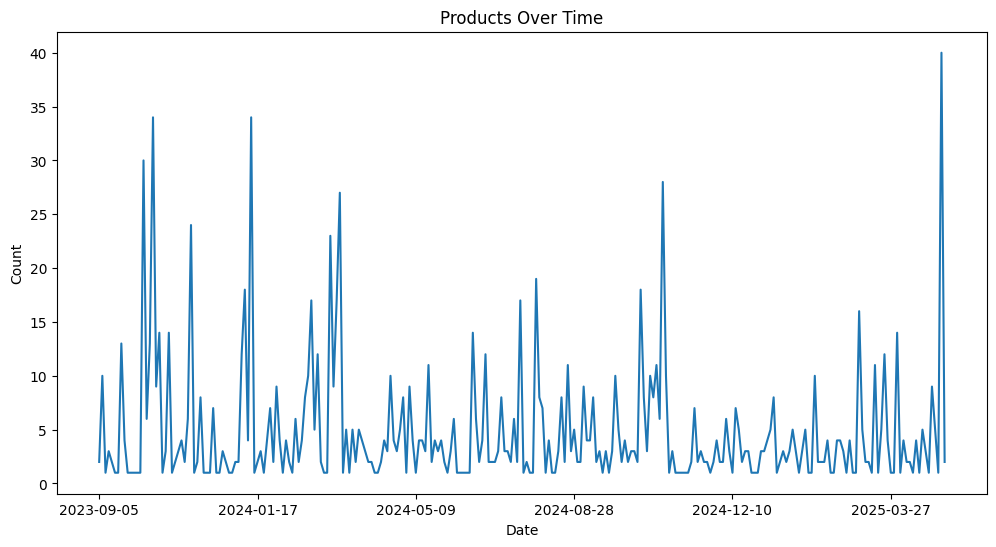

In [20]:
plt.figure(figsize=(12, 6))
df_sp.groupby('Proj_Date').size().plot()
plt.title('Products Over Time')
plt.xlabel('Date')
plt.ylabel('Count')
plt.show()

### Criando datasets semanais

In [21]:
df_sp_ferragens_grouped['Proj_Date'] = pd.to_datetime(df_sp_ferragens_grouped['Proj_Date'])  
df_sp_construcao_civil_grouped['Proj_Date'] = pd.to_datetime(df_sp_construcao_civil_grouped['Proj_Date'])  
df_sp_materiais_eletricos_grouped['Proj_Date'] = pd.to_datetime(df_sp_materiais_eletricos_grouped['Proj_Date'])  
  
df_sp_ferragens_grouped.set_index('Proj_Date', inplace=True)  
df_sp_construcao_civil_grouped.set_index('Proj_Date', inplace=True)  
df_sp_materiais_eletricos_grouped.set_index('Proj_Date', inplace=True) 

### Criando datasets quinzenais

In [22]:
df_sp_ferragens_semanal = df_sp_ferragens_grouped.resample('W').sum().reset_index()  
df_sp_construcao_civil_semanal = df_sp_construcao_civil_grouped.resample('W').sum().reset_index()  
df_sp_materiais_eletricos_semanal = df_sp_materiais_eletricos_grouped.resample('W').sum().reset_index() 


#df_sp_ferragens_semanal.to_csv('../Data/PreparedData/SP/Semanal/SP_FERRAGENS.csv', index=False)
#df_sp_construcao_civil_semanal.to_csv('../Data/PreparedData/SP/Semanal/SP_CONSTRUCAO_CIVIL.csv', index=False)
#df_sp_materiais_eletricos_semanal.to_csv('../Data/PreparedData/SP/Semanal/SP_MATERIAIS_ELETRICOS.csv', index=False)

In [23]:
df_sp_ferragens_quinzenal = df_sp_ferragens_grouped.resample('15D').sum().reset_index()  
df_sp_construcao_civil_quinzenal = df_sp_construcao_civil_grouped.resample('15D').sum().reset_index()  
df_sp_materiais_eletricos_quinzenal = df_sp_materiais_eletricos_grouped.resample('15D').sum().reset_index()  

#df_sp_ferragens_quinzenal.to_csv('../Data/PreparedData/SP/Quinzenal/SP_FERRAGENS.csv', index=False)
#df_sp_construcao_civil_quinzenal.to_csv('../Data/PreparedData/SP/Quinzenal/SP_CONSTRUCAO_CIVIL.csv', index=False)
#df_sp_materiais_eletricos_quinzenal.to_csv('../Data/PreparedData/SP/Quinzenal/SP_MATERIAIS_ELETRICOS.csv', index=False)

## Estado: RS

In [24]:
df_rs = df[df['Proj_State'] == 'RS']
df_rs.drop(columns=['Prod_Desc', 'Sub_Name', 'ID_Proj', 'Proj_Name', 'Proj_City'], inplace=True)
df_rs.head()

C:\Users\celso\AppData\Local\Temp\ipykernel_16296\597132560.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_rs.drop(columns=['Prod_Desc', 'Sub_Name', 'ID_Proj', 'Proj_Name', 'Proj_City'], inplace=True)


,Cat_Name,BOM_Quant,Proj_State,Proj_Date
5,Construção Civil,10.64,RS,2023-09-06
18,Construção Civil,10.00,RS,2023-09-06
36,Construção Civil,1.00,RS,2023-09-19
37,Construção Civil,1.00,RS,2023-09-19
38,Construção Civil,1.00,RS,2023-09-19


In [25]:
df_rs.isnull().sum()

Cat_Name      0
BOM_Quant     0
Proj_State    0
Proj_Date     0
dtype: int64

### Criando um dataset para cada categoria que sera modelada

In [26]:
df_rs_ferragens = df_rs[df_rs['Cat_Name'] == 'Ferragens']
df_rs_construcao_civil = df_rs[df_rs['Cat_Name'] == 'Construção Civil']
df_rs_materiais_eletricos = df_rs[df_rs['Cat_Name'] == 'Materiais Elétricos']

### Agrupamento e Soma de BOM_Quant por Data

In [27]:
df_rs_ferragens_grouped = df_rs_ferragens.groupby('Proj_Date').agg({'BOM_Quant': 'sum'}).reset_index()
df_rs_construcao_civil_grouped = df_rs_construcao_civil.groupby('Proj_Date').agg({'BOM_Quant': 'sum'}).reset_index()
df_rs_materiais_eletricos_grouped = df_rs_materiais_eletricos.groupby('Proj_Date').agg({'BOM_Quant': 'sum'}).reset_index()

In [28]:
n_duplicates = df_rs_ferragens_grouped.duplicated().sum()
print(f'Número de duplicados: {n_duplicates}')

n_duplicates = df_rs_construcao_civil_grouped.duplicated().sum()
print(f'Número de duplicados: {n_duplicates}')

n_duplicates = df_rs_materiais_eletricos_grouped.duplicated().sum()
print(f'Número de duplicados: {n_duplicates}')


Número de duplicados: 0
Número de duplicados: 0
Número de duplicados: 0


In [29]:
# Verificando se há valores zero ou negativos
print(df_rs_ferragens_grouped[df_rs_ferragens_grouped['BOM_Quant'] <= 0].shape[0])
print(df_rs_construcao_civil_grouped[df_rs_construcao_civil_grouped['BOM_Quant'] <= 0].shape[0])
print(df_rs_materiais_eletricos_grouped[df_rs_materiais_eletricos_grouped['BOM_Quant'] <= 0].shape[0])


0
0
0


In [30]:
#df_rs_ferragens_grouped.to_csv('../Data/PreparedData/RS/RS_FERRAGENS.csv', index=False)
#df_rs_construcao_civil_grouped.to_csv('../Data/PreparedData/RS/RS_CONSTRUCAO_CIVIL.csv', index=False)
#df_rs_materiais_eletricos_grouped.to_csv('../Data/PreparedData/RS/RS_MATERIAIS_ELETRICOS.csv', index=False)

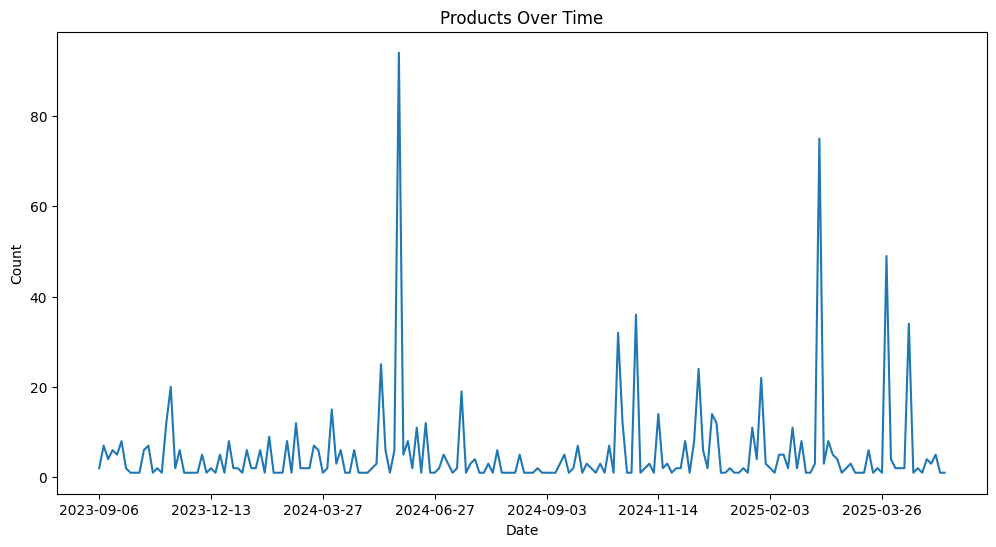

In [31]:
plt.figure(figsize=(12, 6))
df_rs.groupby('Proj_Date').size().plot()
plt.title('Products Over Time')
plt.xlabel('Date')
plt.ylabel('Count')
plt.show()

### Criando datasets semanais

In [32]:
df_rs_ferragens_grouped['Proj_Date'] = pd.to_datetime(df_rs_ferragens_grouped['Proj_Date'])  
df_rs_construcao_civil_grouped['Proj_Date'] = pd.to_datetime(df_rs_construcao_civil_grouped['Proj_Date'])  
df_rs_materiais_eletricos_grouped['Proj_Date'] = pd.to_datetime(df_rs_materiais_eletricos_grouped['Proj_Date'])  
  
df_rs_ferragens_grouped.set_index('Proj_Date', inplace=True)  
df_rs_construcao_civil_grouped.set_index('Proj_Date', inplace=True)  
df_rs_materiais_eletricos_grouped.set_index('Proj_Date', inplace=True) 

In [33]:
df_rs_ferragens_semanal = df_rs_ferragens_grouped.resample('W').sum().reset_index()  
df_rs_construcao_civil_semanal = df_rs_construcao_civil_grouped.resample('W').sum().reset_index()  
df_rs_materiais_eletricos_semanal = df_rs_materiais_eletricos_grouped.resample('W').sum().reset_index() 


#df_rs_ferragens_semanal.to_csv('../Data/PreparedData/RS/Semanal/RS_FERRAGENS.csv', index=False)
#df_rs_construcao_civil_semanal.to_csv('../Data/PreparedData/RS/Semanal/RS_CONSTRUCAO_CIVIL.csv', index=False)
#df_rs_materiais_eletricos_semanal.to_csv('../Data/PreparedData/RS/Semanal/RS_MATERIAIS_ELETRICOS.csv', index=False)

### Criando datasets quinzenais

In [34]:
df_rs_ferragens_quinzenal = df_rs_ferragens_grouped.resample('15D').sum().reset_index()  
df_rs_construcao_civil_quinzenal = df_rs_construcao_civil_grouped.resample('15D').sum().reset_index()  
df_rs_materiais_eletricos_quinzenal = df_rs_materiais_eletricos_grouped.resample('15D').sum().reset_index()  

#df_rs_ferragens_quinzenal.to_csv('../Data/PreparedData/RS/Quinzenal/RS_FERRAGENS.csv', index=False)
#df_rs_construcao_civil_quinzenal.to_csv('../Data/PreparedData/RS/Quinzenal/RS_CONSTRUCAO_CIVIL.csv', index=False)
#df_rs_materiais_eletricos_quinzenal.to_csv('../Data/PreparedData/RS/Quinzenal/RS_MATERIAIS_ELETRICOS.csv', index=False)

In [35]:
bases_agregadas = {
    "rj_ferragens_semanal": df_rj_ferragens_semanal,
    "rj_ferragens_quinzenal": df_rj_ferragens_quinzenal,
    "rj_construcao_civil_semanal": df_rj_construcao_civil_semanal,
    "rj_construcao_civil_quinzenal": df_rj_construcao_civil_quinzenal,
    "rj_materiais_eletricos_semanal": df_rj_materiais_eletricos_semanal,
    "rj_materiais_eletricos_quinzenal": df_rj_materiais_eletricos_quinzenal,

    "sp_ferragens_semanal": df_sp_ferragens_semanal,
    "sp_ferragens_quinzenal": df_sp_ferragens_quinzenal,
    "sp_construcao_civil_semanal": df_sp_construcao_civil_semanal,
    "sp_construcao_civil_quinzenal": df_sp_construcao_civil_quinzenal,
    "sp_materiais_eletricos_semanal": df_sp_materiais_eletricos_semanal,
    "sp_materiais_eletricos_quinzenal": df_sp_materiais_eletricos_quinzenal,

    "rs_ferragens_semanal": df_rs_ferragens_semanal,
    "rs_ferragens_quinzenal": df_rs_ferragens_quinzenal,
    "rs_construcao_civil_semanal": df_rs_construcao_civil_semanal,
    "rs_construcao_civil_quinzenal": df_rs_construcao_civil_quinzenal,
    "rs_materiais_eletricos_semanal": df_rs_materiais_eletricos_semanal,
    "rs_materiais_eletricos_quinzenal": df_rs_materiais_eletricos_quinzenal,
}

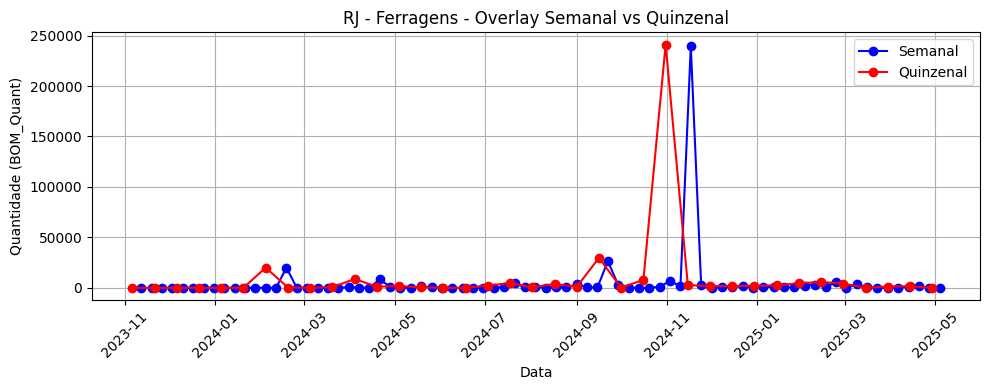

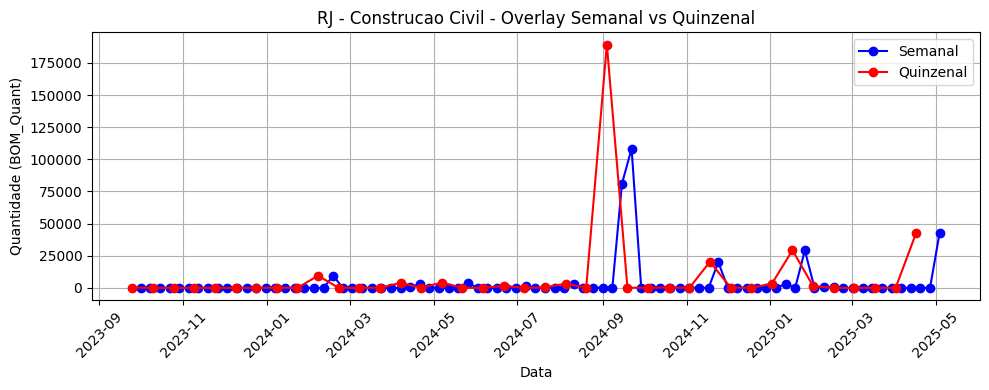

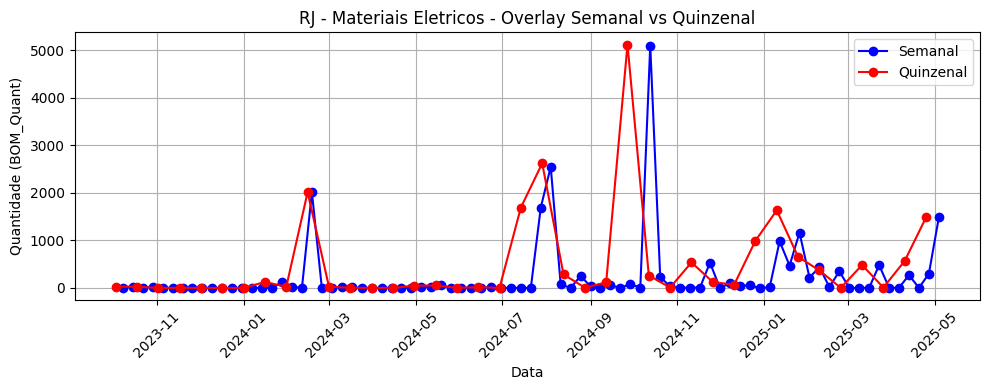

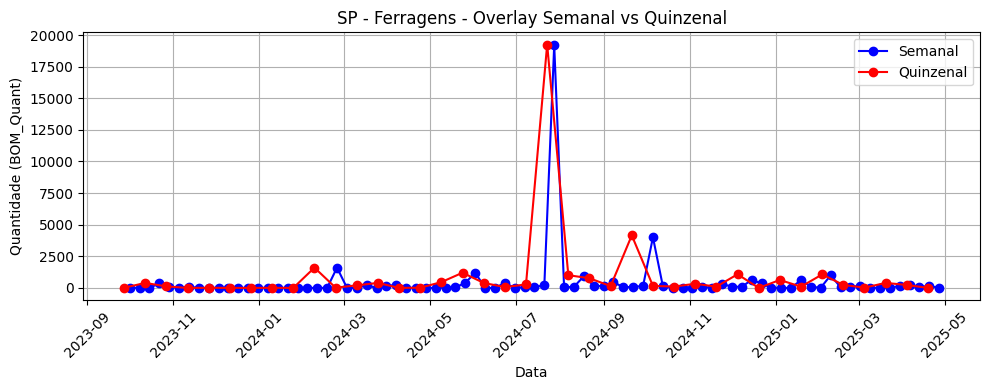

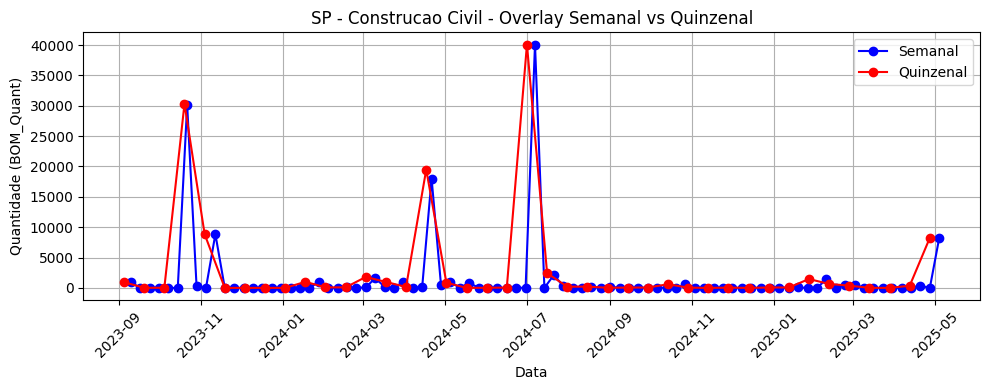

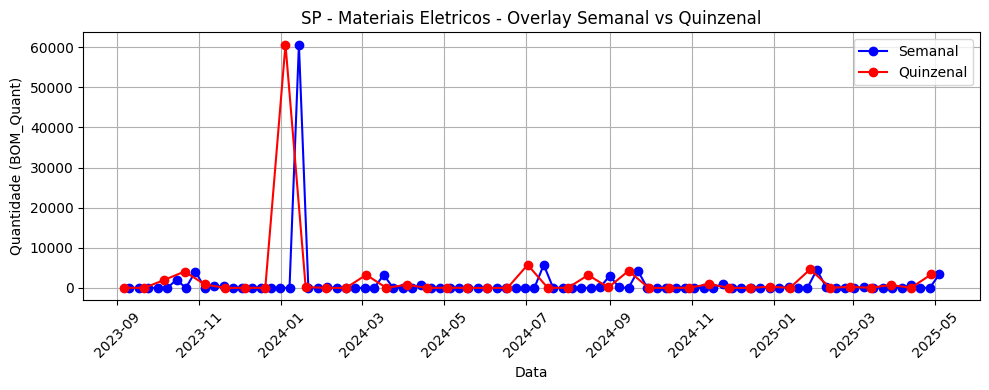

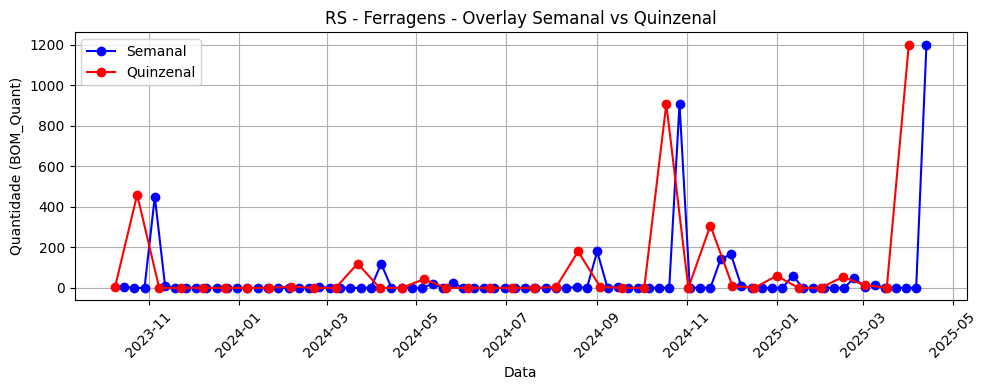

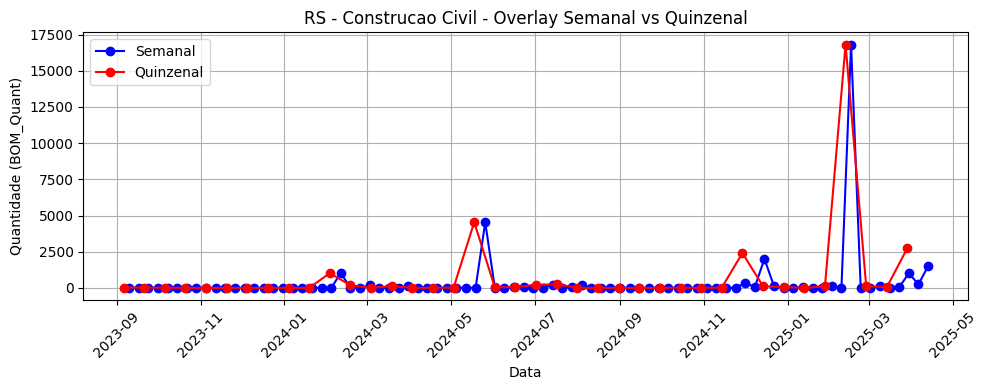

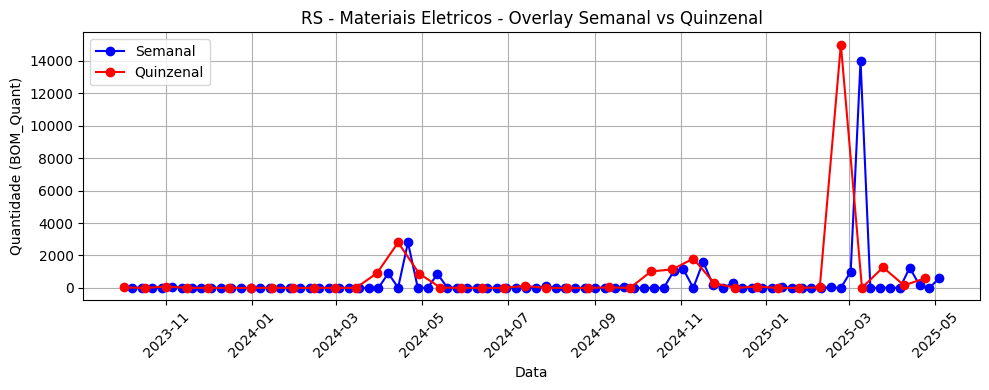

In [36]:
estados = ["rj", "sp", "rs"]
categorias = ["ferragens", "construcao_civil", "materiais_eletricos"]

for estado in estados:
    for cat in categorias:
        nome_semanal = f"{estado}_{cat}_semanal"
        nome_quinzenal = f"{estado}_{cat}_quinzenal"

        df_sem = bases_agregadas.get(nome_semanal)
        df_quin = bases_agregadas.get(nome_quinzenal)

        if df_sem is not None and df_quin is not None:
            plt.figure(figsize=(10, 4))
            plt.plot(df_sem["Proj_Date"], df_sem["BOM_Quant"], marker='o', color='blue', label='Semanal')
            plt.plot(df_quin["Proj_Date"], df_quin["BOM_Quant"], marker='o', color='red', label='Quinzenal')
            plt.title(f"{estado.upper()} - {cat.replace('_', ' ').title()} - Overlay Semanal vs Quinzenal")
            plt.xlabel("Data")
            plt.ylabel("Quantidade (BOM_Quant)")
            plt.grid(True)
            plt.legend()
            plt.xticks(rotation=45)
            plt.tight_layout()
            plt.show()

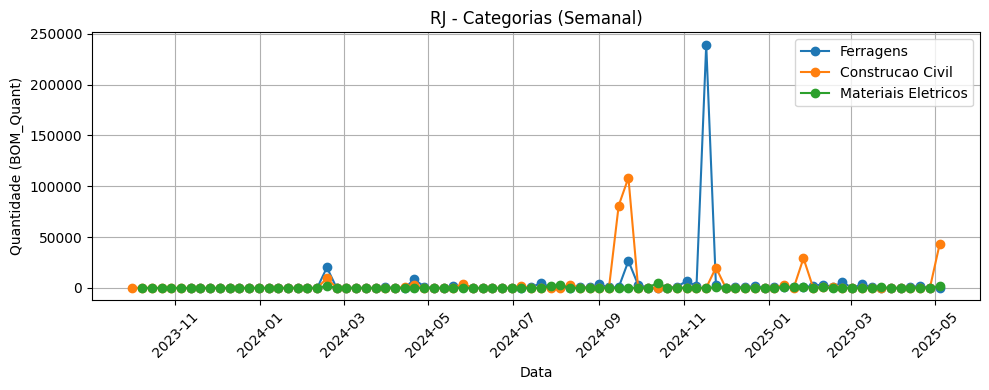

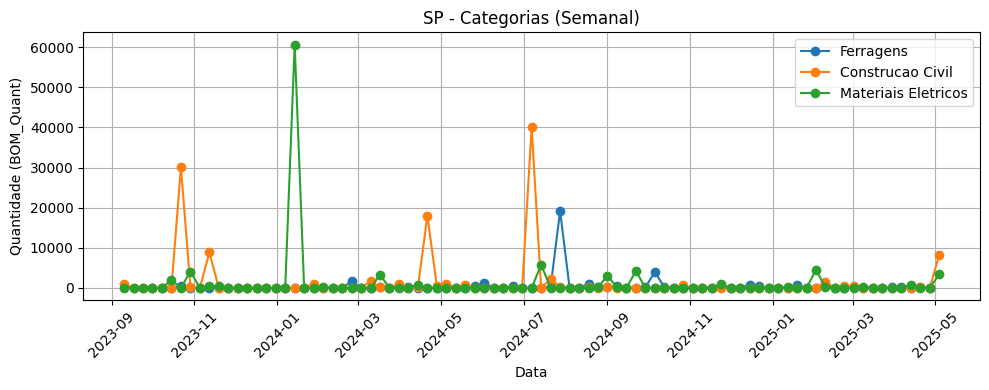

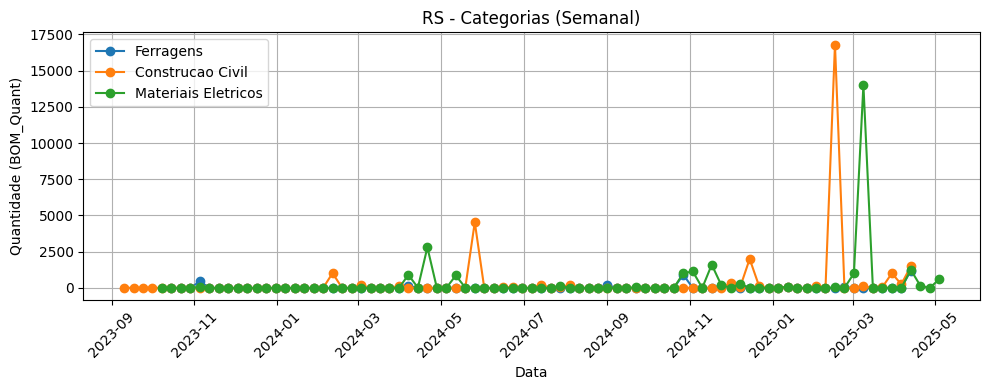

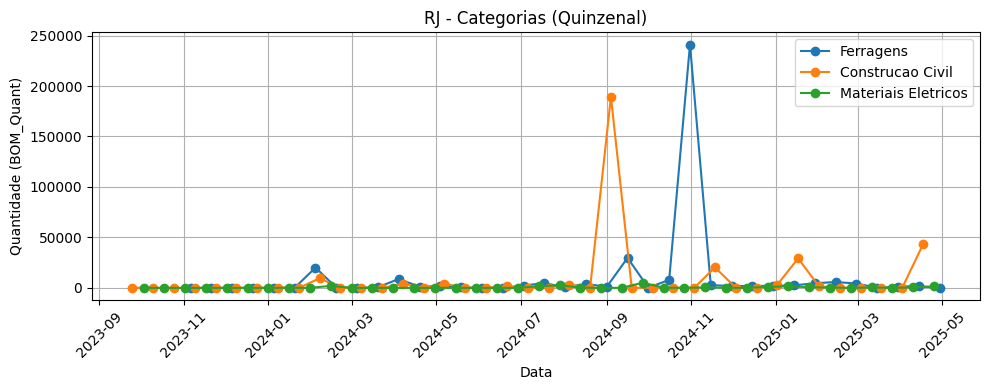

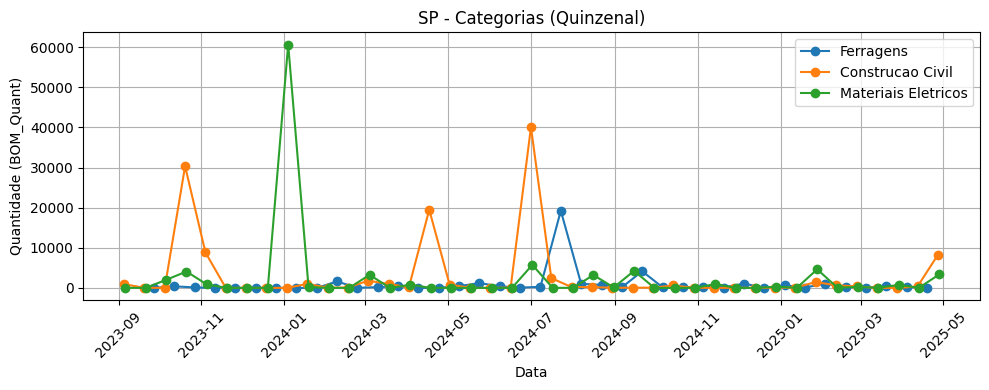

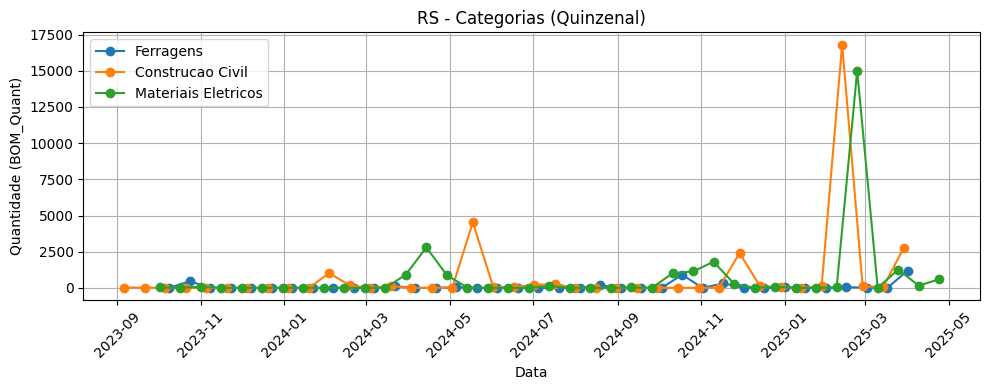

In [37]:
import matplotlib.pyplot as plt

# Lista de estados e categorias
estados = ["rj", "sp", "rs"]
categorias = ["ferragens", "construcao_civil", "materiais_eletricos"]

# Gráficos semanais por estado
for estado in estados:
    plt.figure(figsize=(10, 4))
    for cat in categorias:
        nome = f"{estado}_{cat}_semanal"
        df = bases_agregadas.get(nome)
        if df is not None:
            plt.plot(df["Proj_Date"], df["BOM_Quant"], marker='o', label=cat.replace("_", " ").title())
    plt.title(f"{estado.upper()} - Categorias (Semanal)")
    plt.xlabel("Data")
    plt.ylabel("Quantidade (BOM_Quant)")
    plt.grid(True)
    plt.legend()
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

# Gráficos quinzenais por estado
for estado in estados:
    plt.figure(figsize=(10, 4))
    for cat in categorias:
        nome = f"{estado}_{cat}_quinzenal"
        df = bases_agregadas.get(nome)
        if df is not None:
            plt.plot(df["Proj_Date"], df["BOM_Quant"], marker='o', label=cat.replace("_", " ").title())
    plt.title(f"{estado.upper()} - Categorias (Quinzenal)")
    plt.xlabel("Data")
    plt.ylabel("Quantidade (BOM_Quant)")
    plt.grid(True)
    plt.legend()
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()


In [40]:
def decompor_e_plotar(df, titulo):
    df = df.copy()
    df = df.set_index("Proj_Date").asfreq("2W-MON")

    # Preenche valores ausentes com o anterior e, se ainda restar, com 0
    df["BOM_Quant"] = df["BOM_Quant"].fillna(method='ffill').fillna(0)

    decomposicao = seasonal_decompose(df["BOM_Quant"], model="additive", period=2)

    plt.figure(figsize=(12, 8))
    plt.suptitle(titulo, fontsize=14)
    decomposicao.observed.plot(ax=plt.subplot(411), title='Observado')
    decomposicao.trend.plot(ax=plt.subplot(412), title='Tendência')
    decomposicao.seasonal.plot(ax=plt.subplot(413), title='Sazonalidade')
    decomposicao.resid.plot(ax=plt.subplot(414), title='Resíduo')
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()



C:\Users\celso\AppData\Local\Temp\ipykernel_16296\1007263881.py:6: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df["BOM_Quant"] = df["BOM_Quant"].fillna(method='ffill').fillna(0)


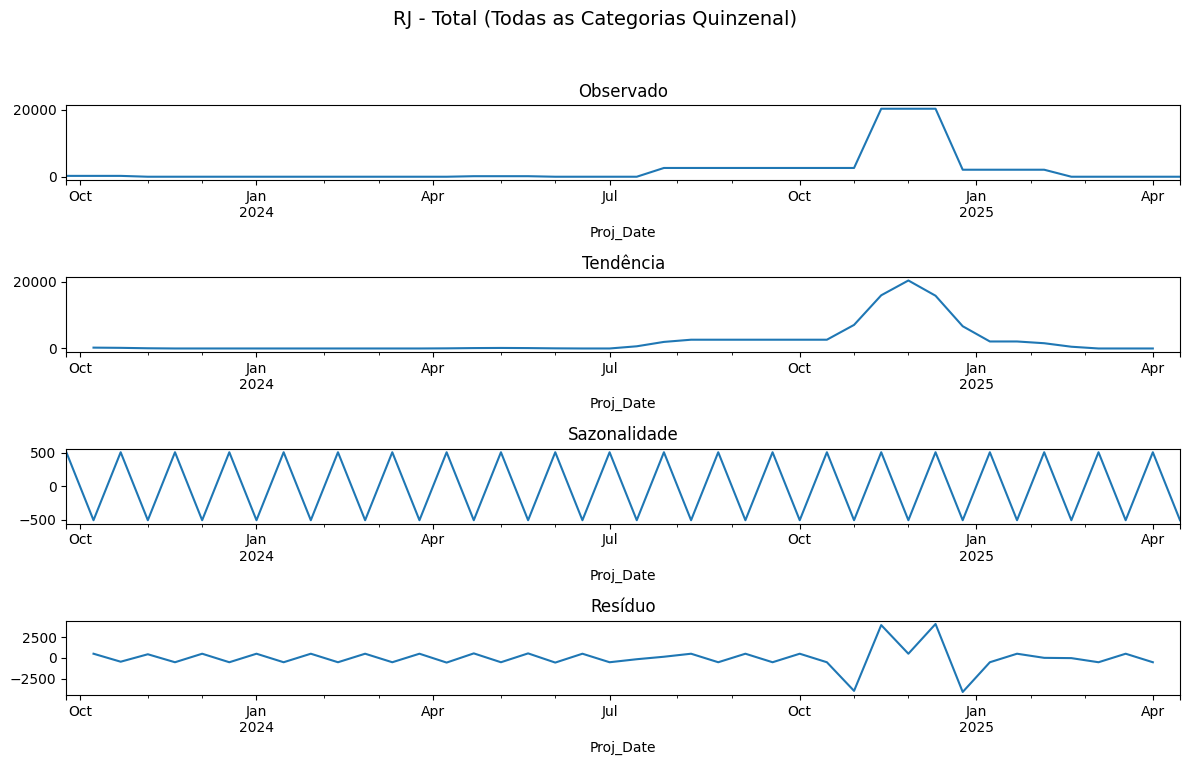

C:\Users\celso\AppData\Local\Temp\ipykernel_16296\1007263881.py:6: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df["BOM_Quant"] = df["BOM_Quant"].fillna(method='ffill').fillna(0)


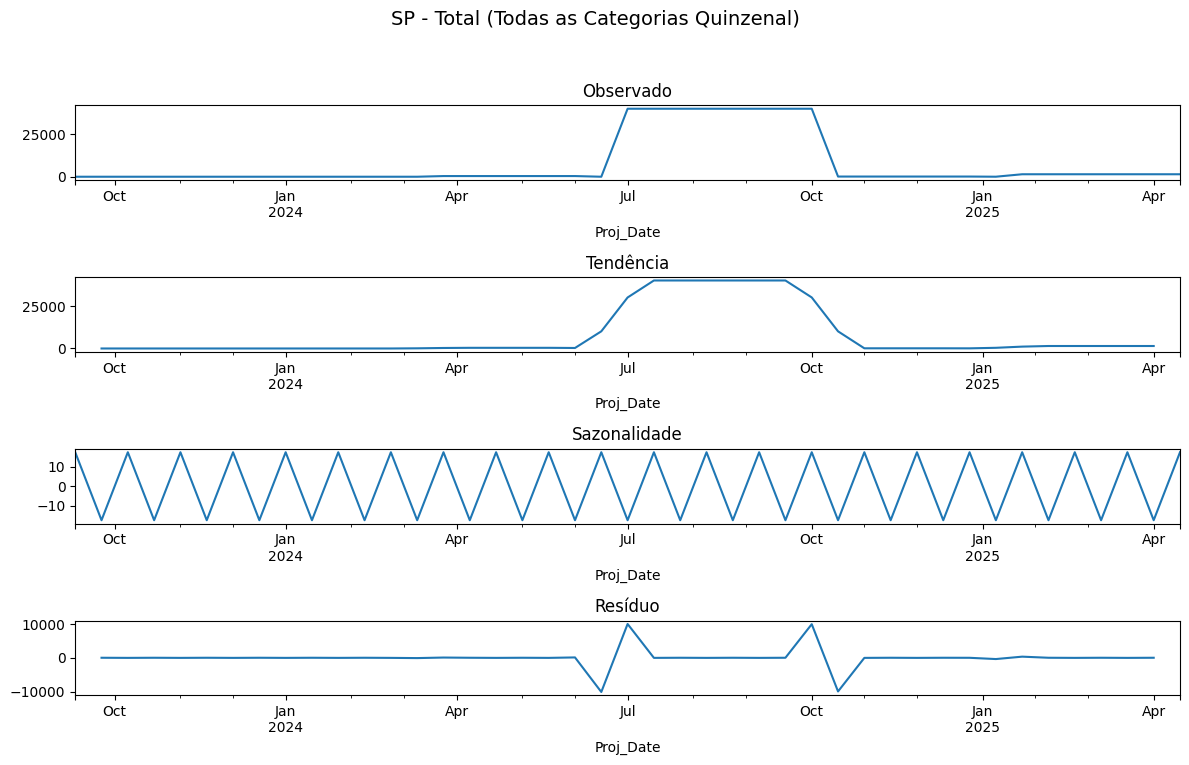

C:\Users\celso\AppData\Local\Temp\ipykernel_16296\1007263881.py:6: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df["BOM_Quant"] = df["BOM_Quant"].fillna(method='ffill').fillna(0)


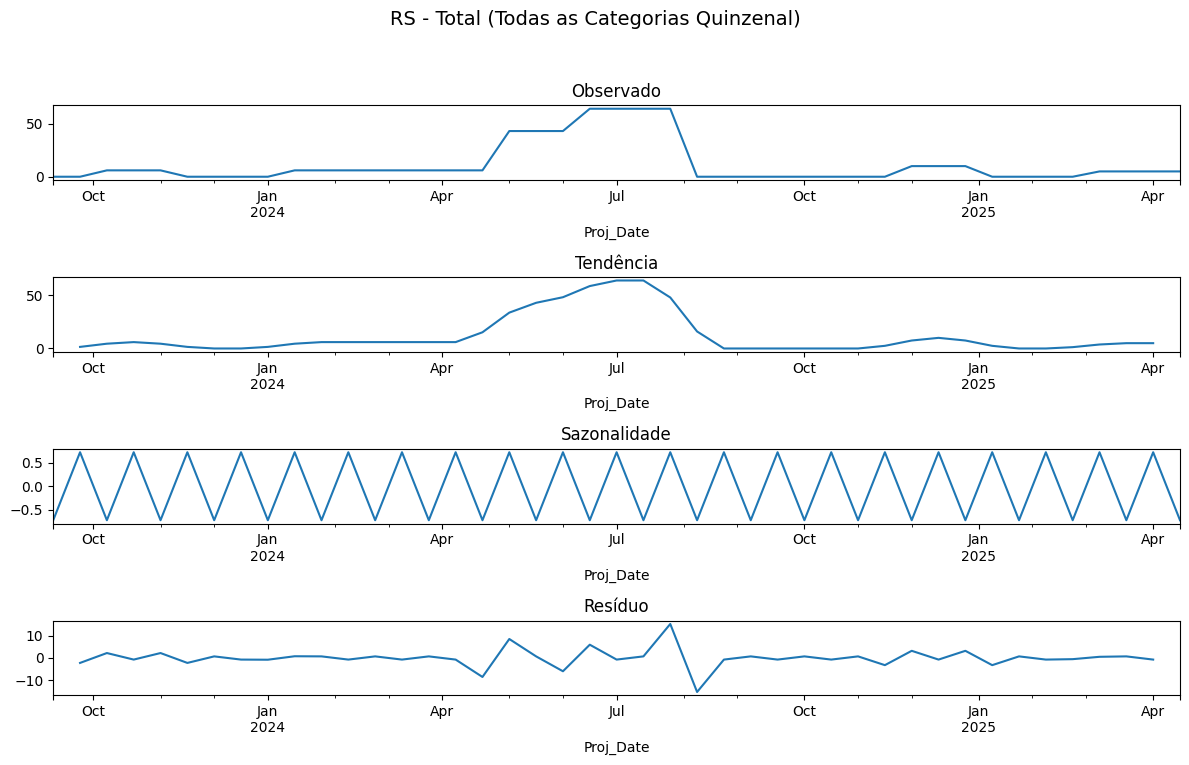

In [41]:
# Estados e categorias definidas dinamicamente
estados = ["rj", "sp", "rs"]
categorias = ["ferragens", "construcao_civil", "materiais_eletricos"]

# Total por estado (soma das categorias quinzenais)
for estado in estados:
    dfs = []
    for cat in categorias:
        varname = f"df_{estado}_{cat}_quinzenal"
        if varname in globals():
            dfs.append(globals()[varname])
    if dfs:
        df_total = pd.concat(dfs).groupby("Proj_Date")["BOM_Quant"].sum().reset_index()
        decompor_e_plotar(df_total, f"{estado.upper()} - Total (Todas as Categorias Quinzenal)")


C:\Users\celso\AppData\Local\Temp\ipykernel_16296\1007263881.py:6: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df["BOM_Quant"] = df["BOM_Quant"].fillna(method='ffill').fillna(0)


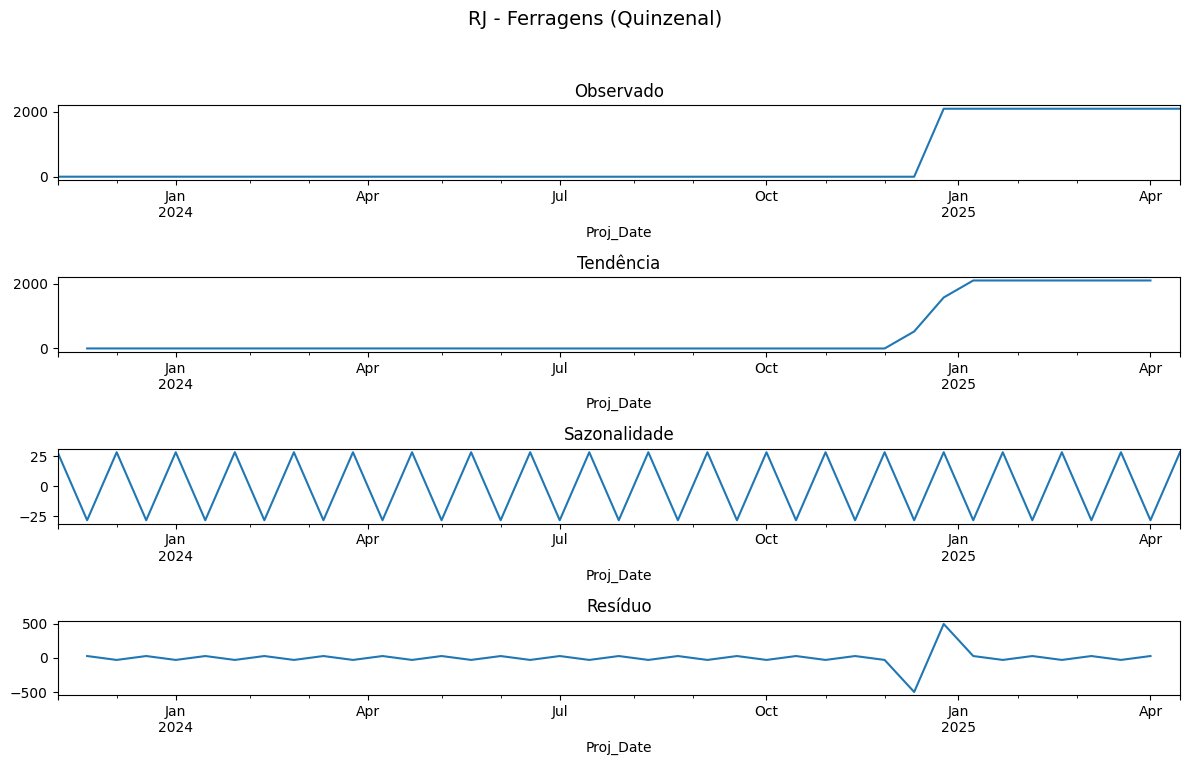

C:\Users\celso\AppData\Local\Temp\ipykernel_16296\1007263881.py:6: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df["BOM_Quant"] = df["BOM_Quant"].fillna(method='ffill').fillna(0)


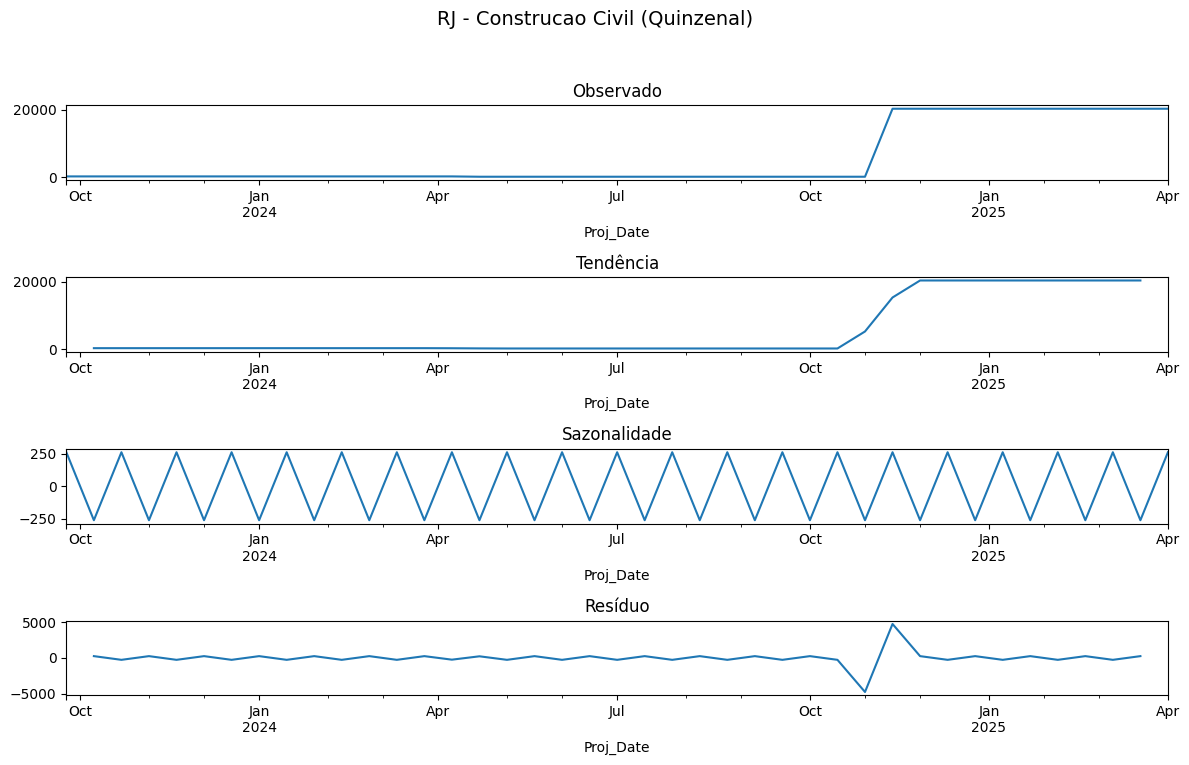

C:\Users\celso\AppData\Local\Temp\ipykernel_16296\1007263881.py:6: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df["BOM_Quant"] = df["BOM_Quant"].fillna(method='ffill').fillna(0)


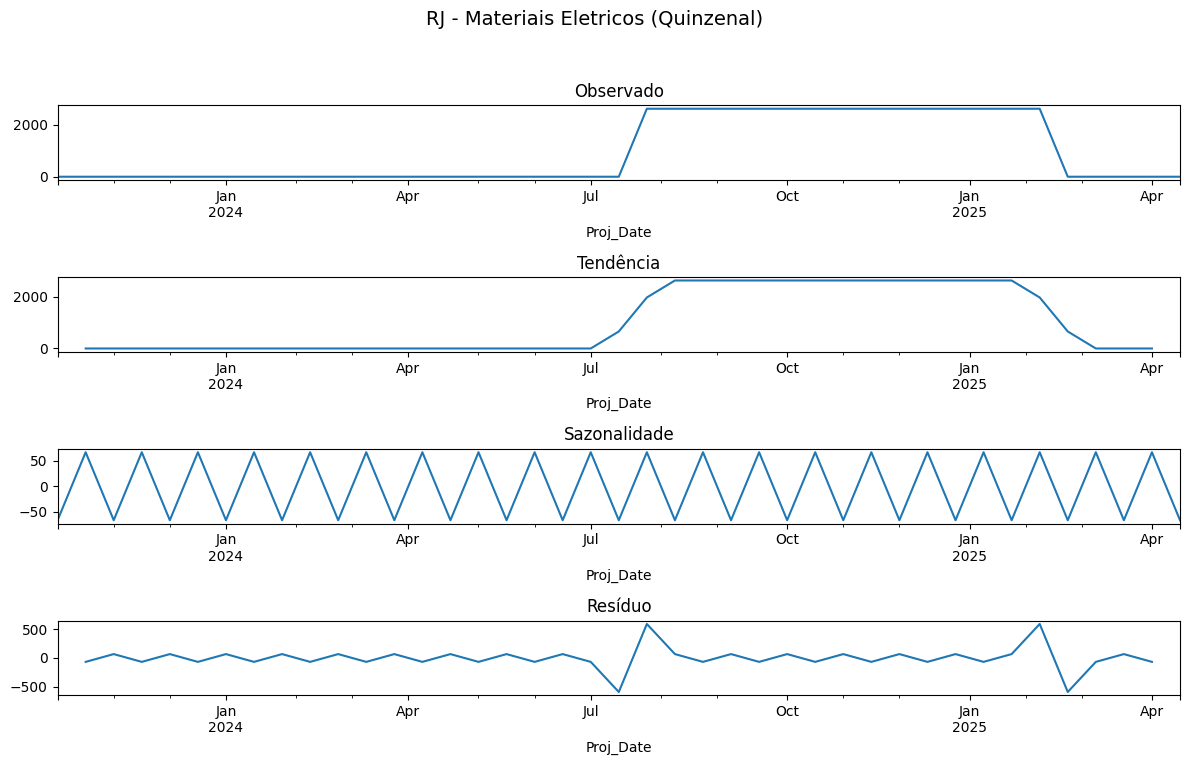

C:\Users\celso\AppData\Local\Temp\ipykernel_16296\1007263881.py:6: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df["BOM_Quant"] = df["BOM_Quant"].fillna(method='ffill').fillna(0)


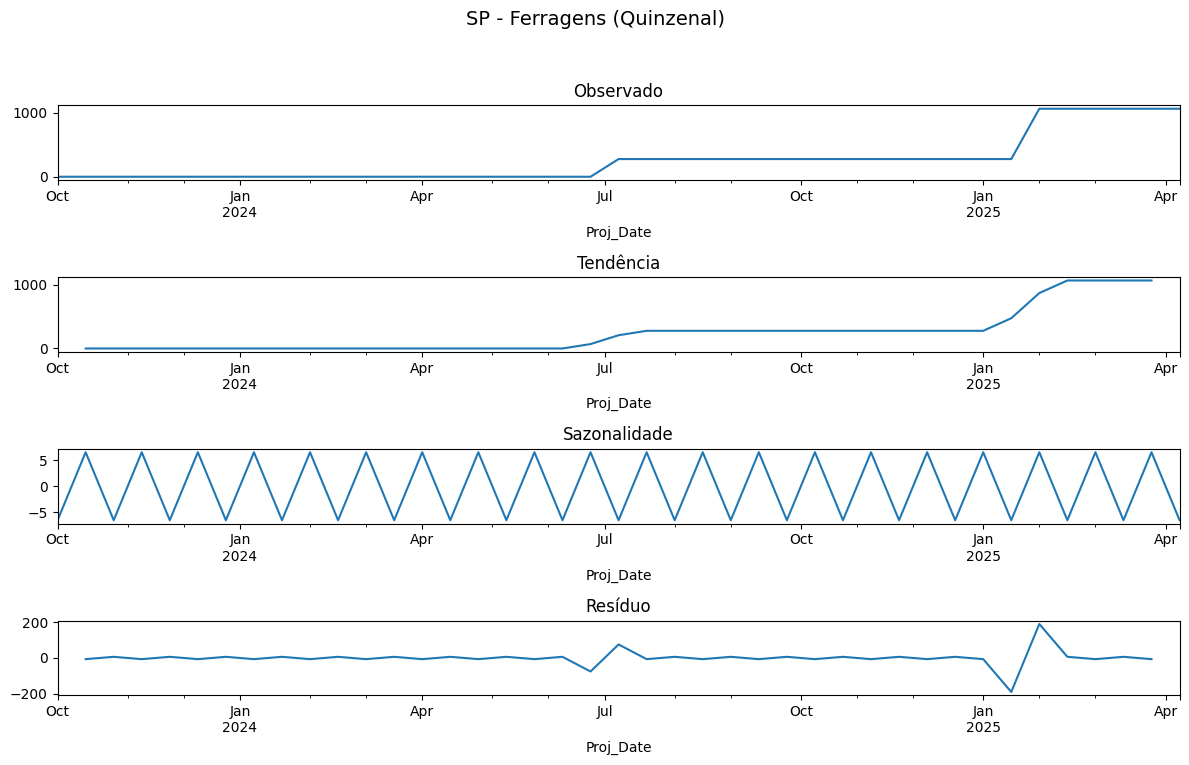

C:\Users\celso\AppData\Local\Temp\ipykernel_16296\1007263881.py:6: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df["BOM_Quant"] = df["BOM_Quant"].fillna(method='ffill').fillna(0)


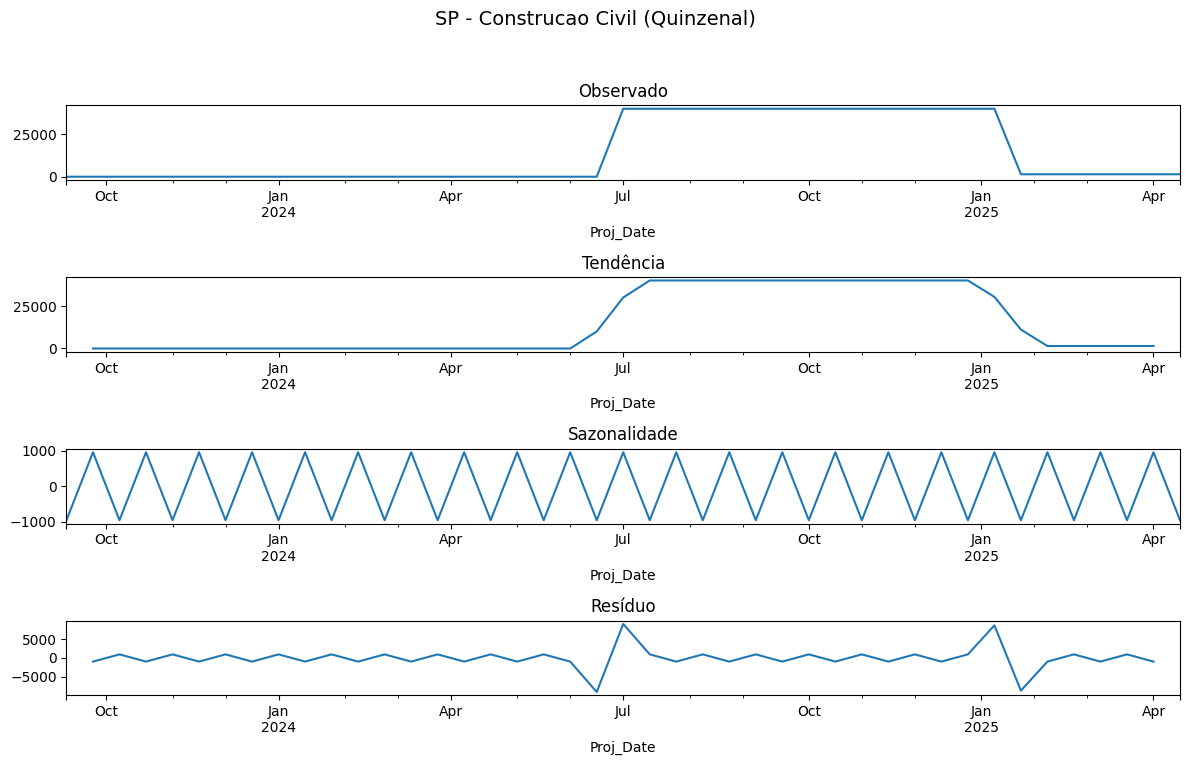

C:\Users\celso\AppData\Local\Temp\ipykernel_16296\1007263881.py:6: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df["BOM_Quant"] = df["BOM_Quant"].fillna(method='ffill').fillna(0)


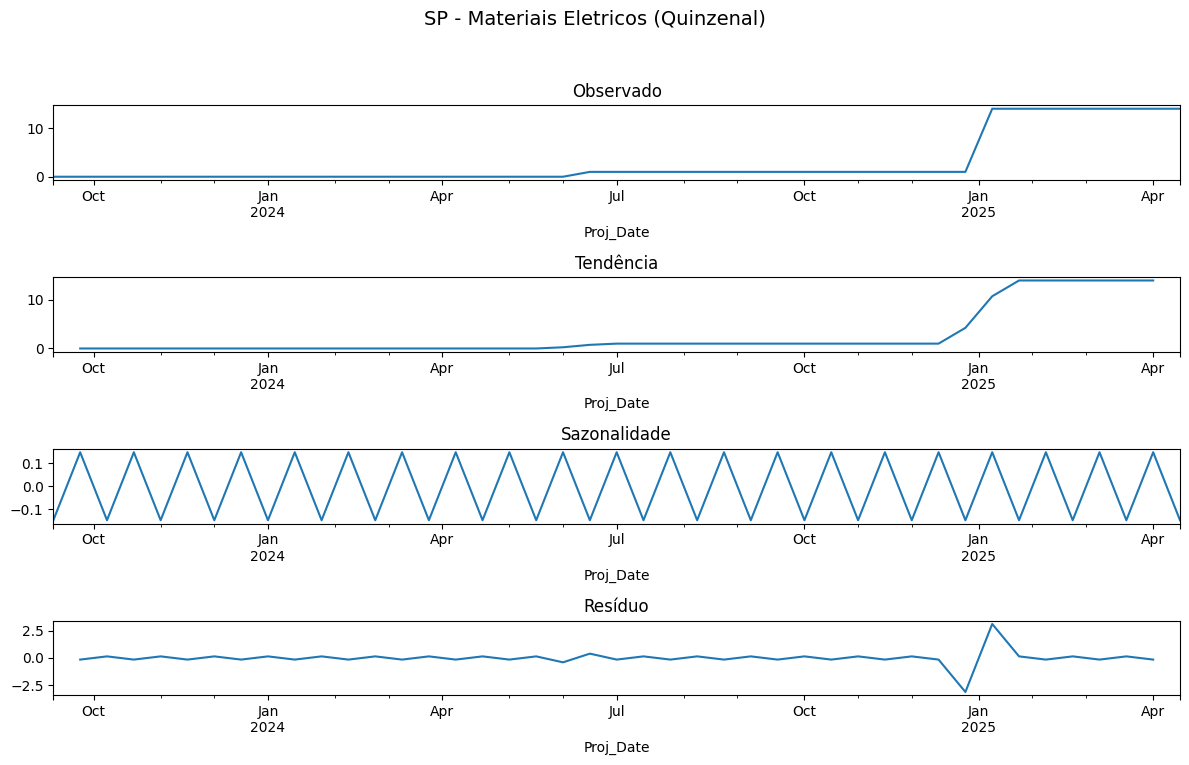

C:\Users\celso\AppData\Local\Temp\ipykernel_16296\1007263881.py:6: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df["BOM_Quant"] = df["BOM_Quant"].fillna(method='ffill').fillna(0)


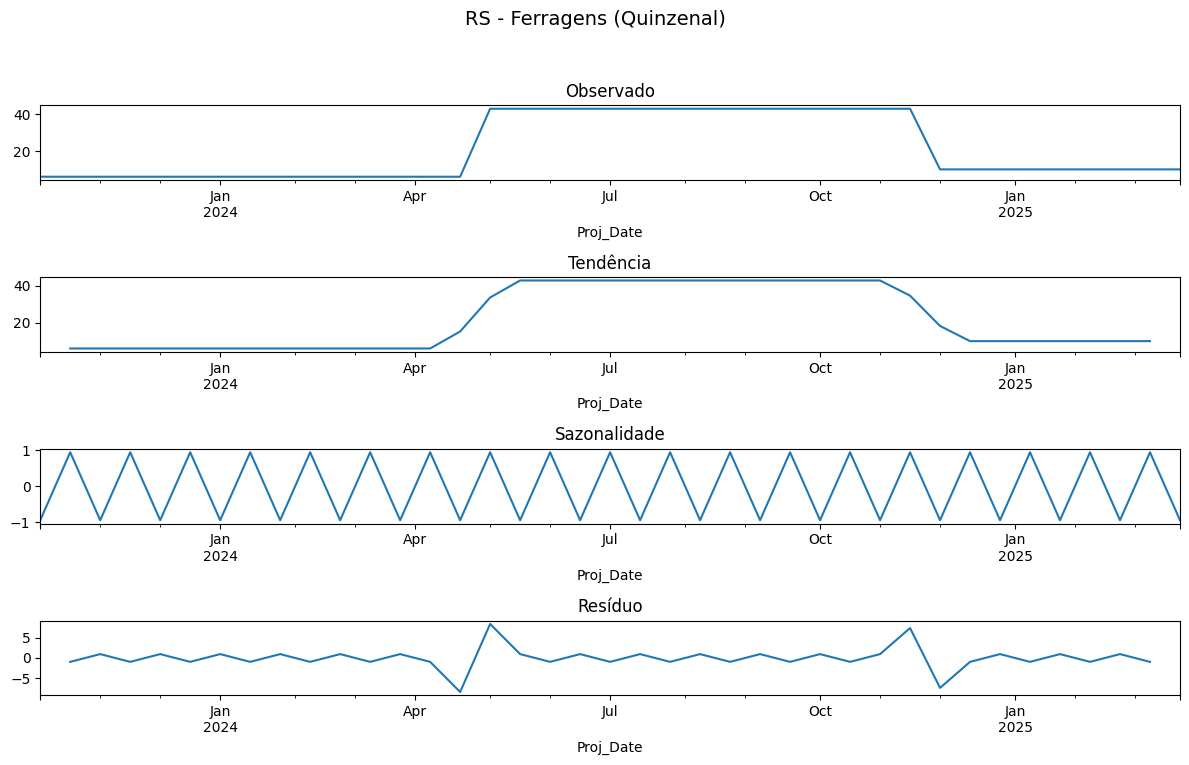

C:\Users\celso\AppData\Local\Temp\ipykernel_16296\1007263881.py:6: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df["BOM_Quant"] = df["BOM_Quant"].fillna(method='ffill').fillna(0)


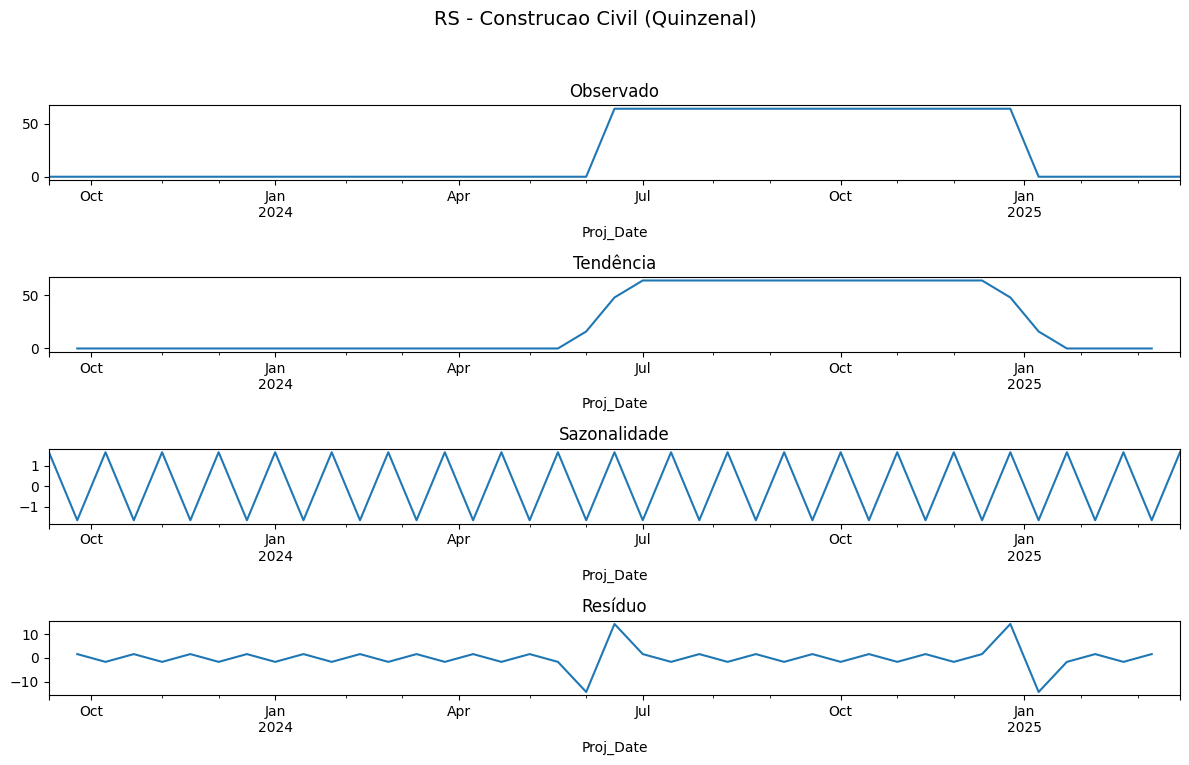

C:\Users\celso\AppData\Local\Temp\ipykernel_16296\1007263881.py:6: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df["BOM_Quant"] = df["BOM_Quant"].fillna(method='ffill').fillna(0)


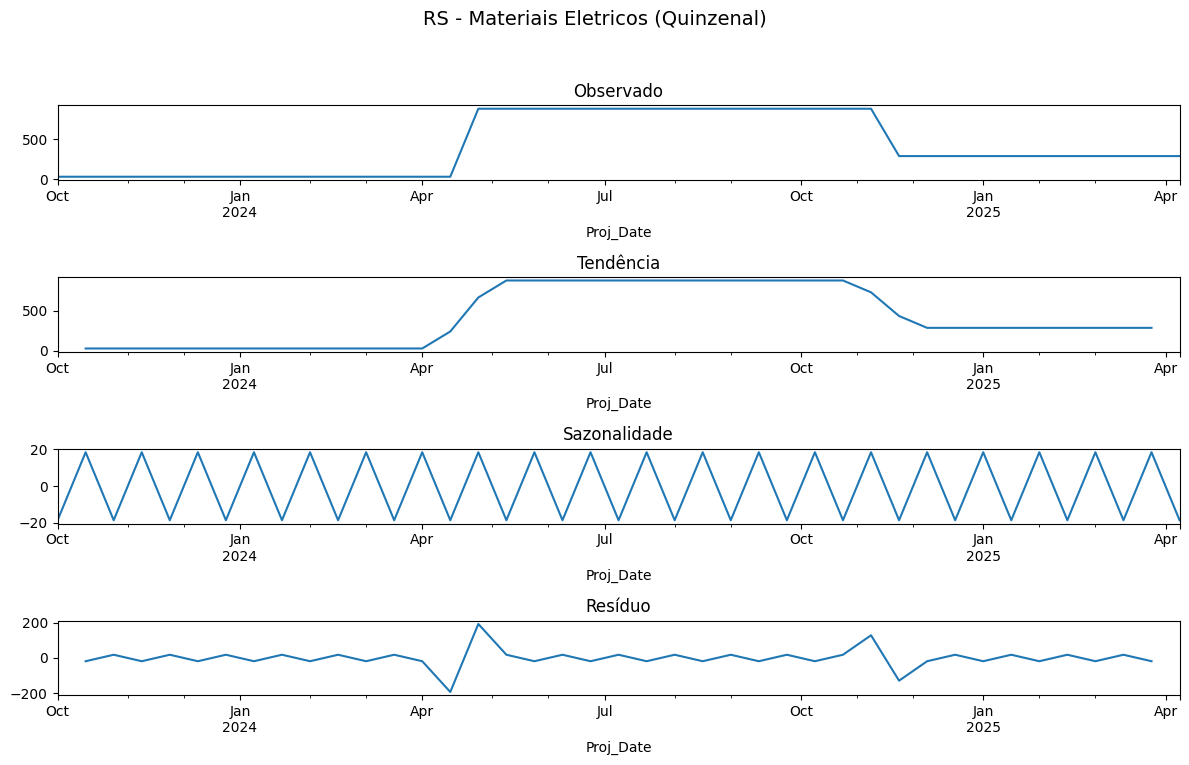

In [42]:
# Decomposição por categoria quinzenal
for estado in estados:
    for cat in categorias:
        varname = f"df_{estado}_{cat}_quinzenal"
        if varname in globals():
            df = globals()[varname]
            titulo = f"{estado.upper()} - {cat.replace('_', ' ').title()} (Quinzenal)"
            decompor_e_plotar(df, titulo)
